SBI + NODDI

Here is NODDI
I simulate NODDI according to ball and stick model you have given me. So they keep the same structure

In [1]:
import torch
import numpy as np

import sbi.utils as utils
from sbi.inference.base import infer

# Read in bvals and bvecs
bvals = torch.tensor(np.loadtxt('./bvals'), dtype=float) #/ 1000.0
bvecs = torch.tensor(np.loadtxt('./bvecs'), dtype=float)


# Forward model with NODDI
def forward(p):
    
    # s0: Initial MR signal
    # d_ic: Diffusivity inter cell
    # d_ec: Diffusivity extra cell
    # d_iso: Diffusivity isotropic
    # th, ph: Neurite orientation
    # f_ic: Inter cell fraction
    # f_iso: Isotropic fraction
    s0, d_ic, d_ec, d_iso, th, ph, f_ic, f_iso = p
    
    # Spherical -> Cartesian
    n = torch.tensor([torch.sin(th) * torch.cos(ph), torch.sin(th) * torch.sin(ph), torch.cos(th)])
    
    # Dot product of fiber orientation and bvec
    ang = torch.sum((n[:, None] * bvecs) ** 2, axis=0)
    
    # Attenuation due to intracellular diffusion
    E_ic = torch.exp(-bvals * d_ic * ang)
    
    # Attenuation due to extracellular diffusion
    E_ec = torch.exp(-bvals * d_ec * (1 - f_ic * ang))
    
    # Attenuation due to isotropic diffusion
    E_iso = torch.exp(-bvals * d_iso)  # Assumed to be similar to extracellular diffusivity
    
    # Return predicted signal
    return s0 * ((1 - f_iso) * (f_ic * E_ic + (1 - f_ic) * E_ec) + f_iso * E_iso)

# Simulator generates noisy data
def simulator_NODDI(parameter_set, noise_std=0.01):
    noise = torch.randn(bvals.shape) * noise_std
    #print(forward(parameter_set) + noise)
    return forward(parameter_set) + noise

# Priors (uniform in this case)
#                                            s0,d_ic,d_ec,d_iso,th,ph,f_ic,f_iso
prior = utils.BoxUniform(low  =torch.tensor([0., 0., 0., 0., -10., -10., 0., 0.]), 
                         high =torch.tensor([2., 3., 3., 3., 10.,  10.,  1., 1.]))

# Example usage of the inference method with the defined model and priors
inference = infer(simulator_NODDI, prior, method='SNPE', num_simulations=1000,num_workers=8)


2024-07-08 15:24:02.355163: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-08 15:24:03.236537: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Running 1000 simulations in 1000 batches.:   0%|          | 0/1000 [00:00<?, ?it/s]

2024-07-08 15:24:06.782537: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-08 15:24:06.838769: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-08 15:24:06.852706: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-08 15:24:06.906777: I tensorflow/core/platform/cpu_featu

 Neural network successfully converged after 31 epochs.

tensor([ 2.6059e-01,  9.8930e-03,  1.2869e-02, -3.1547e-03, -3.0723e-03,
         6.2027e-03,  8.1113e-03,  2.2205e-02,  1.4542e-02, -8.3000e-03,
         1.0202e-02, -2.8197e-03,  9.0797e-03,  1.4375e-02, -5.4640e-03,
         5.9126e-03, -2.5434e-03, -1.8122e-02, -1.0441e-02,  1.7857e-02,
         8.9145e-03,  2.7255e-01,  6.5410e-03,  2.1996e-03,  5.5913e-03,
        -6.2925e-03,  1.3018e-02,  1.5878e-03, -1.4535e-02,  1.1487e-02,
         2.2061e-02,  1.1507e-02, -7.4991e-03,  3.5218e-03, -1.1179e-03,
        -1.1094e-02, -2.6299e-02,  4.2401e-03,  4.3734e-03, -8.9136e-03,
        -1.7814e-02,  4.2542e-03,  2.8151e-01,  2.7750e-03, -3.1398e-03,
         1.2329e-02, -6.3064e-03,  4.5256e-03,  9.6546e-03, -2.2107e-05,
         4.4016e-03,  1.4092e-02,  4.3141e-03, -2.2782e-03, -3.9474e-03,
        -9.0332e-03,  1.0398e-02, -8.4152e-04, -7.2326e-03,  2.3000e-03,
         1.9544e-03, -9.3158e-03, -1.8940e-02,  2.7635e-01, -2.1271e-03,
        -7.0982e-03,  7.4141e-03,  1.4136e-02, -2.9

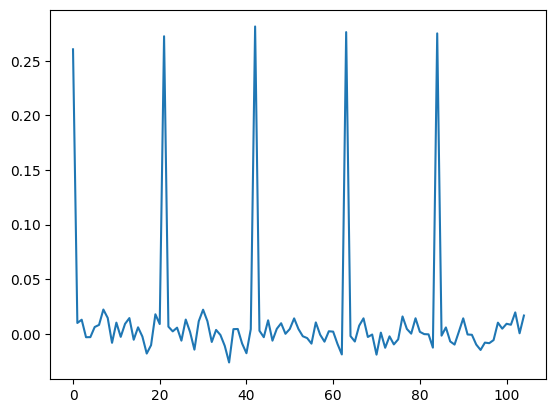

In [2]:
# Generate a new observation
import matplotlib.pyplot as plt
true_p = torch.tensor([1.0, 0.7, 0.3, 0.3, 0.7854, 1.0472, 0.5, 0.2])
observation = simulator_NODDI(true_p)
print(observation)
plt.plot(observation)

In [3]:
# Sample from posterior
samples     = inference.sample((10000,), x=observation)

Drawing 10000 posterior samples: 10433it [00:00, 45900.57it/s]                  


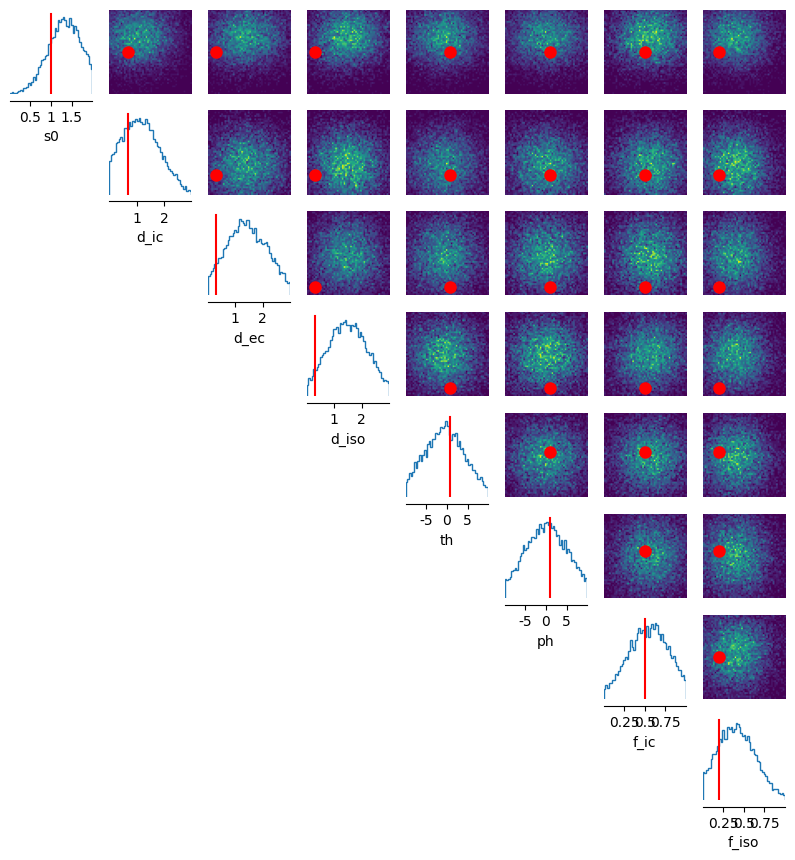

In [4]:
from sbi import utils as utils
from sbi import analysis as analysis
fig, axes = analysis.pairplot(samples,
                              fig_size=(15,15),
                              points=true_p, labels=['s0', 'd_ic', 'd_ec', 'd_iso', 'th', 'ph', 'f_ic', 'f_iso'],
                              points_offdiag={'markersize': 16},
                              points_colors='r');

In [5]:
import tensorflow as tf

# Check if GPU is available
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Check if TensorFlow is currently using GPU
print("TensorFlow GPU:", tf.test.is_built_with_cuda())

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow GPU: True


2024-06-12 15:41:05.205933: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-06-12 15:41:05.209653: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-06-12 15:41:05.209910: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [6]:
import torch

# Check if GPU is available
print("GPU Available:", torch.cuda.is_available())

# Check if PyTorch is currently using GPU
print("PyTorch GPU:", torch.version.cuda)

GPU Available: True
PyTorch GPU: 12.1
